# MACHINE LEARNING Project PCA + Clustering

## Introduction and objectives

We will work with the ['Wisconsin Diagnostic Breast Cancer'](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) dataset. With it, we will perform some statistical analysis, PCA analysis, project the data into the PCA space, apply k-means over the projected data and compare the results with the real labels.

### Dataset information:

This dataset contains features from a digitized image of a fine needle aspirate (FNA) of a breast mass. The characteristics of the cell nuclei present in the image are described in each column.

<img src=./fnabreast.png width="500">

*Figure 1. Image from the cells of a breast FNA.*

#### Information of the variables:

1) ID number
2) Diagnosis (M = malignant, B = benign).
3) From the 3rd column till the 32nd we have ten real-valued features computed for each cell nucleus:
    1) $radius$ (mean of distances from center to points on the perimeter)
    1) texture (*standard deviation* of gray-scale values)
    1) $perimeter$
    1) $area$
    1) smoothness (local variation in $radius$ lengths)
    1) compactness ($\frac{perimeter^2}{area}\,-1.0$)
    1) concavity (severity of concave portions of the contour)
    1) concave points (number of concave portions of the contour)
    1) symmetry
    1) fractal dimension (*"coastline approximation" - 1*)

The mean, standard error and "worst" or largest (mean of the three largest values) of these features are computed for each image, resulting in 30 features.<br>
For example: field 3 is the Mean Radius, field 13 the Radius SE, field 23 the Worst Radius.


## Data Load and Analysis

#### Python libraries
In the following block of code we import the libraries that we will use:

In [1]:
%matplotlib inline
import numpy as np                      # linear algebra
import pandas as pd                     # data processing
import seaborn as sns                   # data visualization
import matplotlib.pyplot as plt         
from sklearn.decomposition import PCA   # PCA for dimensionality reduction imported from
                                        # sklearn.decomposition (matrix decomposition algorithms)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

<br>

#### Importing the data
With the following code we will load the dataset. 
> Note: Make sure you write the correct relative or absolute path to the dataset.

In [ ]:
data = pd.read_csv('./data/wdbc.csv', 
                   names = ["id", "diagnosis", "radius_mean", "texture_mean", "perimeter_mean",
                            "area_mean", "smoothness_mean", "compactness_mean", "concavity_mean",
                            "concave points_mean", "symmetry_mean", "fractal_dimension_mean",
                            "radius_se", "texture_se", "perimeter_se", "area_se", "smoothness_se",
                            "compactness_se", "concavity_se", "concave points_se", "symmetry_se",
                            "fractal_dimension_se", "radius_worst", "texture_worst",
                            "perimeter_worst", "area_worst", "smoothness_worst",
                            "compactness_worst", "concavity_worst", "concave points_worst",
                            "symmetry_worst", "fractal_dimension_worst"]) 
                            # Since this csv had no header, we added it

data.head(10) # checking the first 10 rows

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


In [ ]:
data.shape # See the dimensions

(569, 32)

With the previous we can have an idea of the dataset contents and with `.shape` we can see that it has a total of 569 rows and 32 columns.

<br>

#### Cleaning the data
1. We are going to remove the 'id' column from the data, since it is not required for this analysis.

In [4]:
data.drop('id', axis=1, inplace=True)

2. Now we will code the malignant and benign into 1 and 0, respectively, in order to obtain numerical data from this column.

In [ ]:
data['diagnosis'] = data['diagnosis'].map({'M':1, 'B':0})
data.head(5)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,1,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,1,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,1,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


<br>

#### Exploring the data
The following are some basic statistics of the numerical data for this dataset:

In [ ]:
data.describe().T.style

,count,mean,std,min,25%,50%,75%,max
diagnosis,569.000000,0.372583,0.483918,0.000000,0.000000,0.000000,1.000000,1.000000
radius_mean,569.000000,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.110000
texture_mean,569.000000,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.280000
perimeter_mean,569.000000,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.500000
area_mean,569.000000,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.000000
smoothness_mean,569.000000,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.163400
compactness_mean,569.000000,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.345400
concavity_mean,569.000000,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.426800
concave points_mean,569.000000,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.201200
symmetry_mean,569.000000,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.304000


This information helps to understand what is happening on the data. We can observe a great diversity in the values related to mean and standard deviation between the different features. This indicates that data normalization is required.

We will explore deeper the distribution of malignant and benign cases:

In [ ]:
diagnosis_distribution = data.diagnosis.value_counts()
print(diagnosis_distribution)

diagnosis
0    357
1    212
Name: count, dtype: int64


We can see that we have a distribution of 357 benign (0) and 212 malignant (1) samples. 
<br>
<br>

#### Data visualization

We will plot this to have it more graphical.

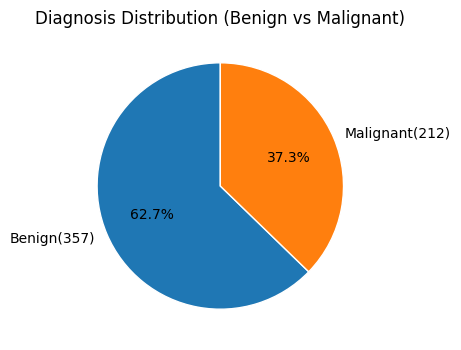

In [ ]:
labels = ["Benign","Malignant"]
sizes = diagnosis_distribution.values # an array with the data counts for each category

plt.figure(figsize=(4,4))
plt.pie(sizes, labels=[f"{label}({count})" for label, count in zip(labels, sizes)],
        autopct='%1.1f%%', startangle=90, wedgeprops={'edgecolor':'white'})
        # %1.1f%% to diplay percenteges
plt.title("Diagnosis Distribution (Benign vs Malignant)")
plt.show()

Now we would like to observe how the means calculated for the nuclear features (`features_mean`) relate to the diagnosis of benign and malignant.<br>
> Note: Remember that the mean characteristics of the nuclear features span from columns 2 to 10.

For this we will perform a **pair plot** to have an overview of all combination of two variables in the dataset associated to the diagnosis of benign (0 = blue) or malignant (1 = orange).

With it we can compare how values of one variable relate to values of another, *i.e.* correlate nuclear features and diagnosis.

Furthermore, we can observe the diagonal of this pair plot which includes the empirical densities of each variable by outcome.

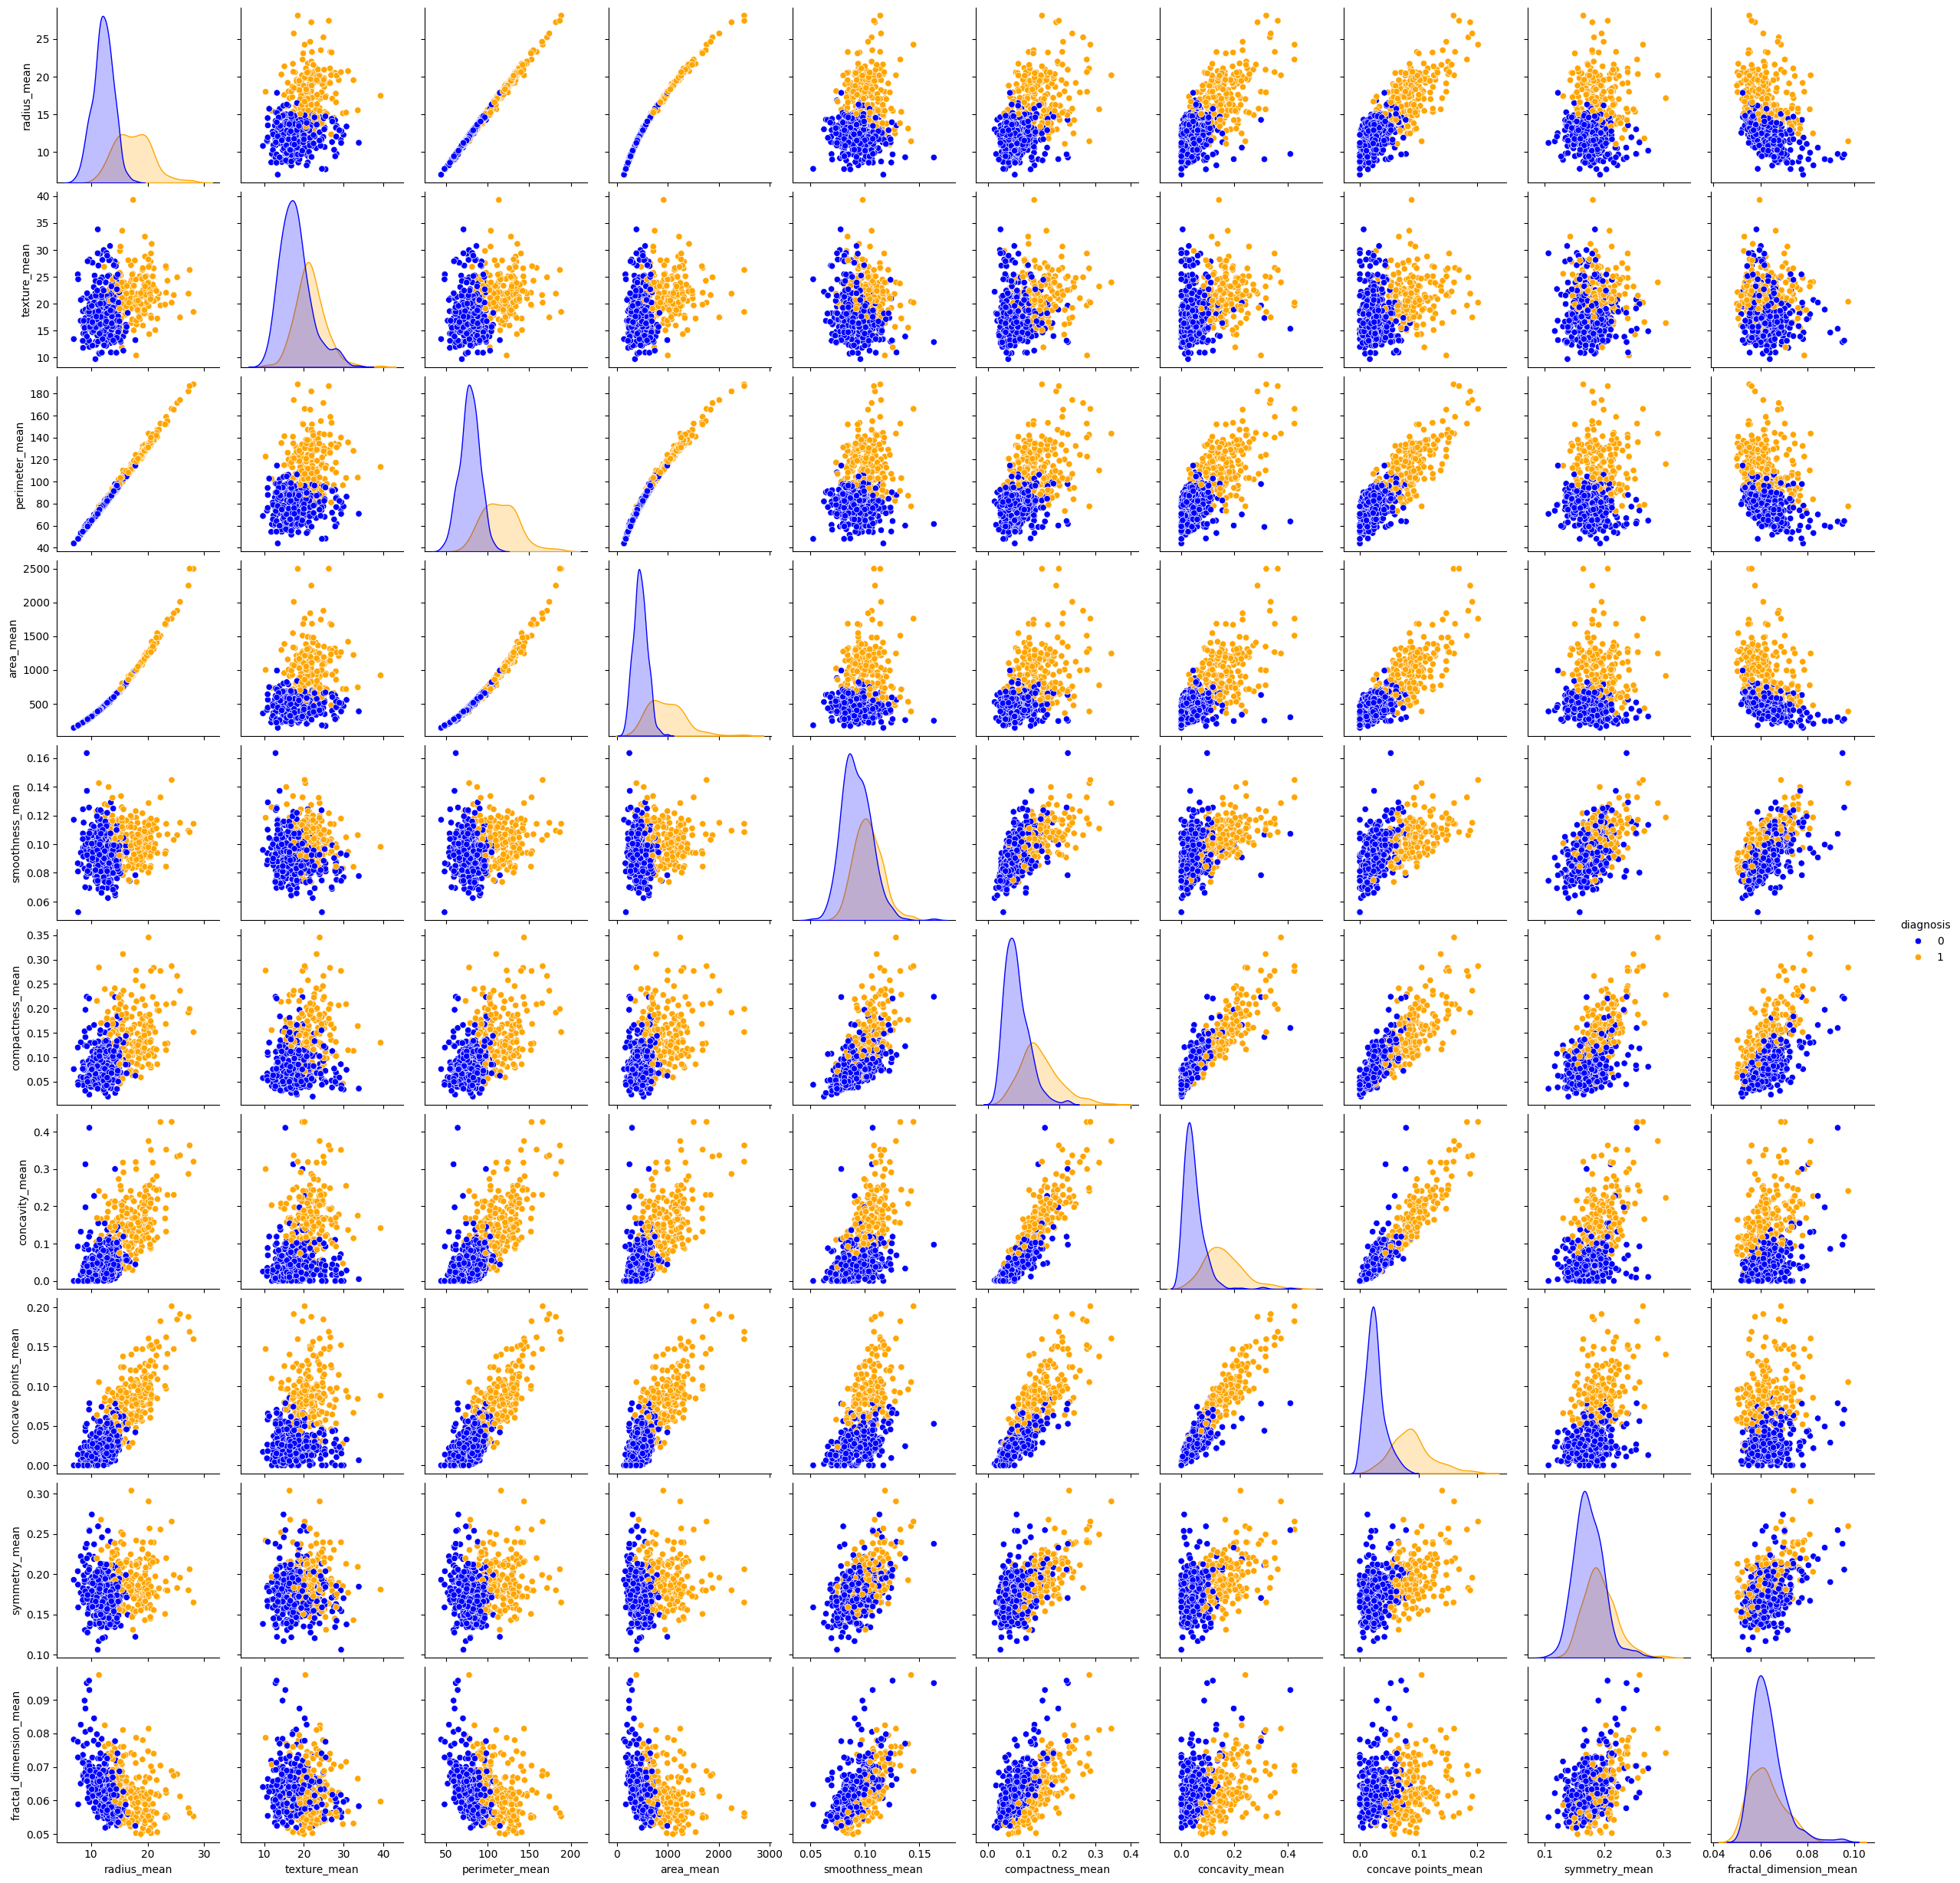

In [ ]:
features_mean = list(data.columns[1:11]) # columns 2 to 10, get the names

sns.pairplot(data, hue='diagnosis', vars=features_mean, palette=["blue", "orange"])
plt.show()

From these results we can take out the following conclusions with regards to the correlation between nuclear features 2x2:

- We can observe that there is a pattern in these 2x2 relationships. For most of them the diagnosis of benign is either situated in the lower left corner or shifted to the left side of the graph, whilst malignant diagnosis are moving away from this area and situated more towards the outer part of the graphs.

- A few features, such as symmetry with texture or smoothness, exhibit a mixture of bening and malignant cases, with no distinct separation between results, meaning that these are not good in terms of classification.

- Lastly, there are a few features where we can observe a strong correlation, for example between perimeter and radius. Either of these features would tell almost all that is explained by the other with regards to diagnosis.

To see what we have in the diagonal more detailed we will separate malignant and benign and plot them together:

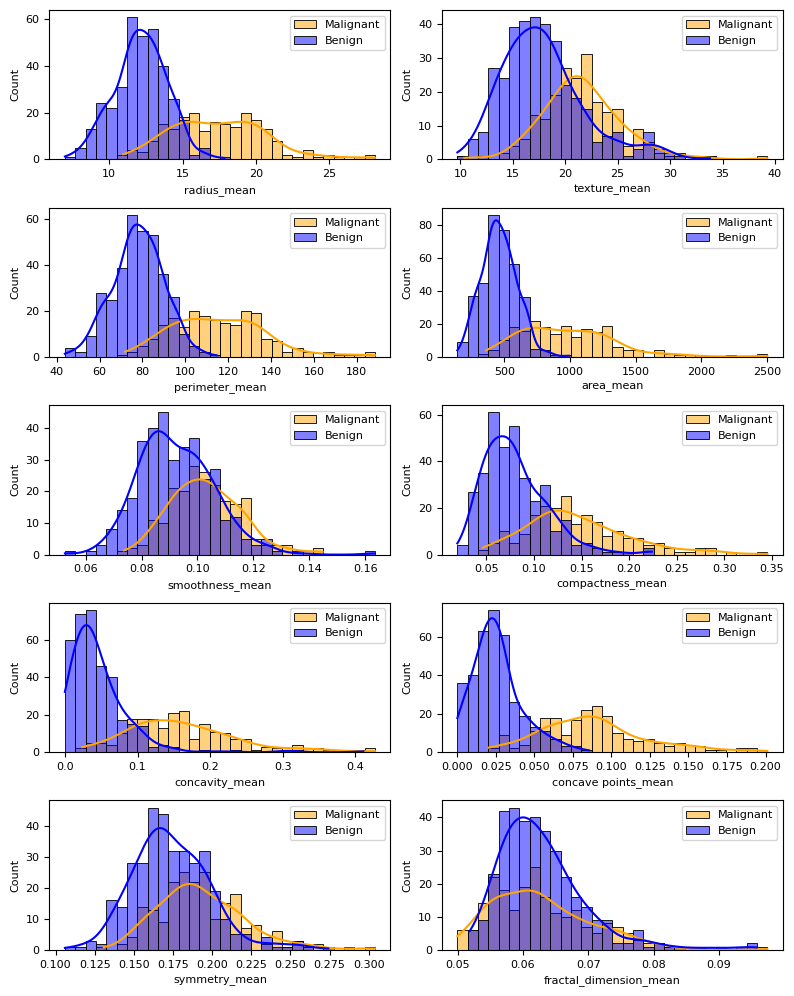

In [ ]:
# Create 2 new sets of data with the malignant and benign cases separately
malignant = data[data['diagnosis'] == 1]
benign = data[data['diagnosis'] == 0]

plt.rcParams.update({'font.size': 8})
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(8, 10))
axes = axes.ravel()  # Flatten the array of axes for easier iteration

# Iterate through features and create histogram plots
for idx, ax in enumerate(axes):
    feature = features_mean[idx]  # Select the feature
    
    # Get per-feature data for malignant and benign
    x_m = malignant[feature]
    x_b = benign[feature]
    
    # Define bins based on the min and max of each feature to get them all the same size
    fmin = data[feature].min()
    fmax = data[feature].max()
    bins = np.linspace(fmin, fmax, 31)
    
    sns.histplot(x=x_m, bins=bins, kde=True, color="orange",
                 label="Malignant", ax=ax)
    sns.histplot(x=x_b, bins=bins, kde=True, color="blue",
                 label="Benign", ax=ax)

    ax.legend(loc='upper right')

plt.tight_layout()
plt.show()


These plots show the distribution of each individual feature. We can observe the relationship of each individual variable versus the outcome of bening and malignant:

- The most discriminant features are the **radius, perimeter, area, compactness** and **concave points**, in these we can observe a clear separation between the malignant and bening curves.

    This means that we can already see that we could identify malignant cells by certain nuclear features such as their larger radius, larger perimeter, larger nuclear area, more level of compactness and larger number of concave points.\
    We could use these features as classification for diagnosis.

- Texture and concavity are not very clear since there are very few bening cells spreading across the where most of the malingnant cells are situated.

- Smoothness, simetry and fractal dimension give the least information on their own, since there is no defnite point where the majority of benign and malignant cells separate.

## 3. Data analysis
### Principal Component Analysis (PCA)

As we could see from the previous statistical analysis some of the data was redundant, therefore here we will aply PCA to the data and explore how much we can reduce the number of variables. The aim is to obtain the principal components that retain most of the original information.

This technique will also fix some issues such as multicollinearity (high correlation between two or more independent variables) and overfitting (poor generalization to new data).

#### Data normalization
Before performing PCA, we need to normalize the data for a better performance, since we have a high variety of results. We will do this by standardizing the values such that they all have a common mean and variance (usually set to be zero and one respectively). This ensures that variance in each dimension happen on roughly the same scale.

In [14]:
# Here we will extract the diagnosis column since we can not use it for PCA
y = data.diagnosis                  # we will save this feature in y
x = data.drop('diagnosis', axis=1)  # x will include all other features
x.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


For normalization we could use the matematical method which scales values between -1 and 1 by taking the data, subtracting the mean and divide it by the range. However this method preserves the outliers because it does not adjust for standard deviation.\
Instead we will use the `StandardScaler` from **Sklearn** which centers the data at 0 and scales it to have unit variance (mean = 0, std = 1). This method is less sensitive to outliers since it normalizes based on standard deviation and therefore is best suited for PCA, ensuring equal variance across features.

In [ ]:
x_std = StandardScaler().fit_transform(x)
print(x_std)

[[ 1.09706398 -2.07333501  1.26993369 ...  2.29607613  2.75062224
   1.93701461]
 [ 1.82982061 -0.35363241  1.68595471 ...  1.0870843  -0.24388967
   0.28118999]
 [ 1.57988811  0.45618695  1.56650313 ...  1.95500035  1.152255
   0.20139121]
 ...
 [ 0.70228425  2.0455738   0.67267578 ...  0.41406869 -1.10454895
  -0.31840916]
 [ 1.83834103  2.33645719  1.98252415 ...  2.28998549  1.91908301
   2.21963528]
 [-1.80840125  1.22179204 -1.81438851 ... -1.74506282 -0.04813821
  -0.75120669]]


#### Explorative PCA

We will perform a PCA analysis exploring the first three PCA dimensions.

In [ ]:
# Perform PCA
n_components = 3
pca = PCA(n_components)
data_pca = pca.fit_transform(x_std)

# Print explained variance ratio
print("Variance explained per component:", pca.explained_variance_ratio_)
print("Total explained variance = ", sum(pca.explained_variance_ratio_))


Variance explained per component: [0.44272026 0.18971182 0.09393163]
Total explained variance =  0.7263637090899083


We can see that if we reduce to three components the explained variance retained is around 72.6%. The first component retains 44.2%, the second 19% and the third 9.4%. We performed a plot to see how these are distributed.

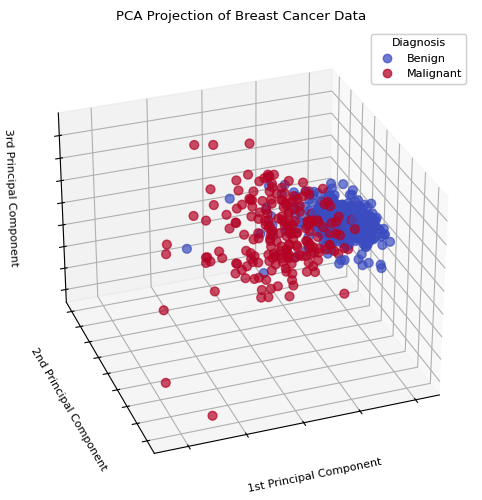

In [ ]:
# Figure
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d", elev=-150, azim=110)

# Scatter plot
scatter = ax.scatter(
    data_pca[:, 0], data_pca[:, 1], data_pca[:, 2],
    c=y, cmap="coolwarm", s=40, alpha=0.7  # Color by diagnosis
)

# Labels
ax.set(title="PCA Projection of Breast Cancer Data",
       xlabel="1st Principal Component",
       ylabel="2nd Principal Component",
       zlabel="3rd Principal Component")

# Remove axis labels
ax.xaxis.set_ticklabels([])
ax.yaxis.set_ticklabels([])
ax.zaxis.set_ticklabels([])

# Add legend
legend1 = ax.legend(
    scatter.legend_elements()[0],
    ["Benign", "Malignant"],
    loc="upper right",
    title="Diagnosis"
)
ax.add_artist(legend1)

# Show plot
plt.show()


We can observe that with a linear combination of the 30 features into 3 features, the main distinction between bening and malignant ocurs from the view the principal component, blue (bening) to the right and red (malignant) to the left. However, since we started of with many features we lost some of the variance that these could explain (27.4%).

In the following blocks we will try to see what would be the optimal number of components to retain at least 95% of variance.

#### Choosing the number of components
We need to estimate how many components are required to better describe the data.

First we will perform a PCA with all the components and use the `explained_variance_ratio_` to observe the explained variance and cumulative variance per component.

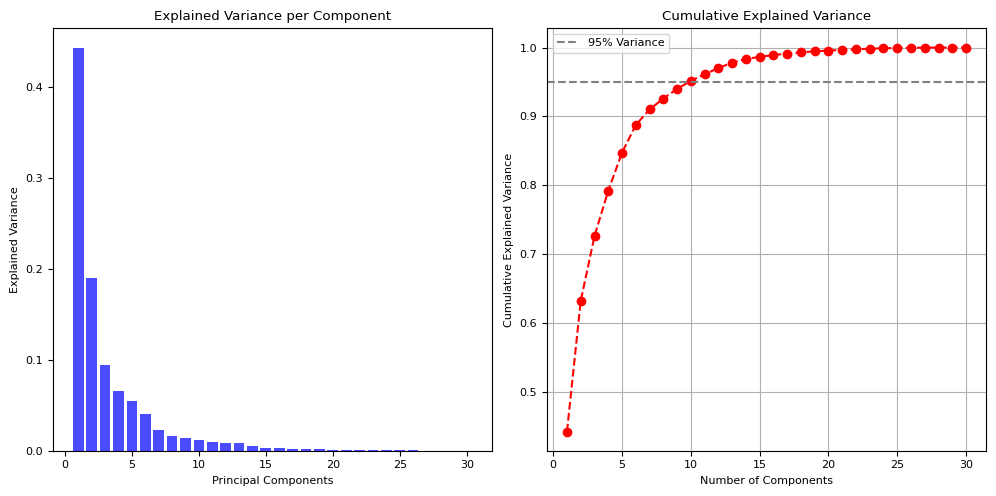

In [ ]:
# Perform PCA with all the components
n_components = 30
pca = PCA(n_components)
data_pca = pca.fit_transform(x_std)
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 5))

# Individual Variance
plt.subplot(1, 2, 1)
plt.bar(range(1, n_components + 1), explained_variance, alpha=0.7, color='b')
plt.xlabel("Principal Components")
plt.ylabel("Explained Variance")
plt.title("Explained Variance per Component")

# Cumulative Variance
plt.subplot(1, 2, 2)
plt.plot(range(1, n_components + 1), cumulative_variance, marker='o', linestyle='--', color='r')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance")

plt.axhline(y=0.95, color='gray', linestyle='--', label="95% Variance")
plt.legend()

plt.tight_layout()
plt.grid(True)
plt.show()

In the previous figures we can see how much of the total variance is captured by the components. There is no drastic change (elbow-like) but we can observe that from component number 6 the changes are smaller. This means that the contribution of each component from there onwards, is very small.

This information can guide us on the level of redundancy present in the dataset. In this case, we can say that the Wisconsin Diagnostic Breast Cancer (WDBC) dataset captured a rather good number of data variation, since we need 26 components to explain 100% of the variance. However, as we can see on the cumulative explained variance (on the right) with aproximately 1/3 of the total number of components we can explain 95% of the variance. 

#### PCA with the optimal number of components

In the following block we will explore the variance and check the exact number of components required to obtain a variance of 95%.

We saw that 3 components are not enough, therefore we start from that number (n_components = 3). Then we will continue making increments in the number of components (+1) and with every iteration calculate the explained variance added every time, until we obtain a sum higher than 95%.

In [ ]:
n_components = 3

while True:
    n_components += 1
    data_pca = PCA(n_components = n_components)
    data_pca.fit(x_std)
    calculation = sum(data_pca.explained_variance_ratio_)
    roundedcalc = round(calculation, 2)
    if roundedcalc >= 0.95:
        break

print("Resulting variance:", roundedcalc)
print("Optimal number of components needed:", n_components)

Resulting variance: 0.95
Optimal number of components needed: 10


In [ ]:
# project the data into this new PCA space
pca = PCA(n_components=10)
x_pca = pca.fit_transform(x_std)

print("Original shape:", x_std.shape)
print("Reduced shape:", x_pca.shape)

Original shape: (569, 30)
Reduced shape: (569, 10)


#### PCA Conclusions
We started with 33 features, with PCA we saw that we could drop this to 10, with an accuracy of 95%. Therefore, although we didn't manage to reduce our data to 2 or 3 dimensions, we did reduced dimensionality by 1/3 without much information loss. This will help to simplify data interpretation and exploration. For that reason, we can conclude that the use of PCA is effective in this case. 

## 4. *k*-means expectation–maximization algorithm

Now we would like to organize the data into groups based on their similarity by using the *k*-means algorithm.

*k*-means is an unsupervised learning algorithm, which works by grouping unlabeled data points into groups of clusters based on the distances to the centroids.

If we plot the newly PCA-Transformed data from the WDBC dataset into a 2D plot, using the first 2 components we optain the following:

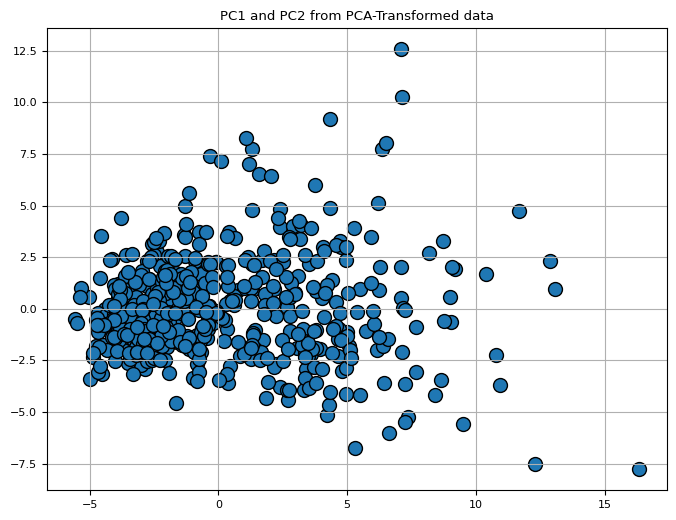

In [ ]:
pca = PCA(n_components=10)
pca.fit(x_std)
df_x_pca = pca.transform(x_std)

# convert dataframe to array
X = np.array(df_x_pca)

# plot first two PC without labels
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], s=100, edgecolor='black')

plt.title('PC1 and PC2 from PCA-Transformed data')

plt.grid(True)
plt.show()

Now we will perform *k*-means on it.
Since we are interested in finding how this data distributes between benign and malignant cases we will try to find 2 clusters:

In [21]:
# Perform KMeans clustering
kmeans2 = KMeans(n_clusters=2, random_state=0)
kmeans2.fit(df_x_pca)
labels = kmeans2.predict(df_x_pca)

To observe the results we will plot them:

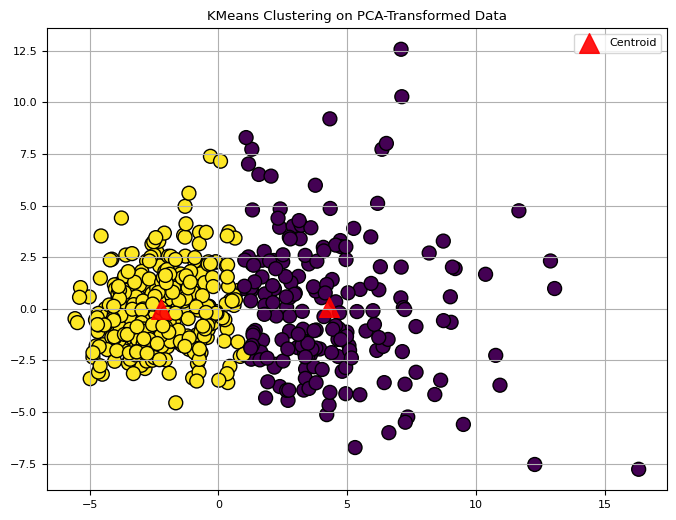

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(df_x_pca[:, 0], df_x_pca[:, 1], c=labels, s=100, cmap='viridis', edgecolor='black')

# plot the cluster centers
centers = kmeans2.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], marker="^", c='red', s=200, alpha=0.9, label='Centroid');

plt.title('KMeans Clustering on PCA-Transformed Data')

plt.grid(True)
plt.legend()
plt.show()

We can see that this is a fair distribution of the data in two clusters. With those that are probably benign in yellow and those probably malignant in purple.

Now, since we already know the real distribution of benign and malignant cells, lets observe how these are truly distributed according to diagnosis. To do this we will use the `y`, which contains diagnosis, that we separated in the first block of "Data normalization":

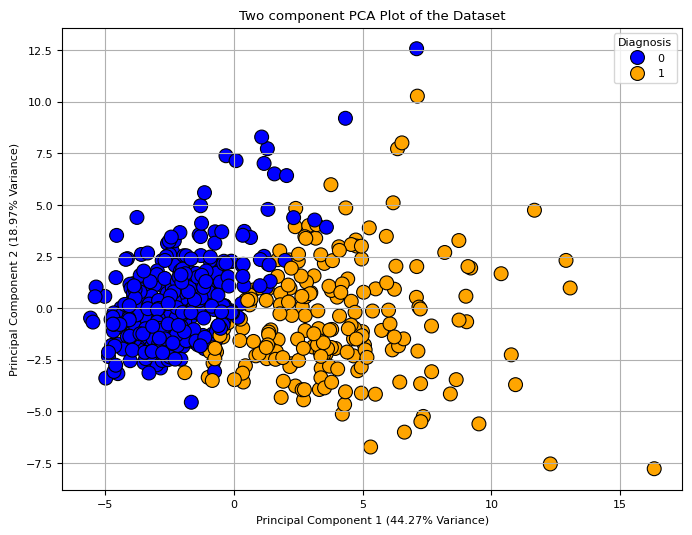

In [ ]:
pca_df = pd.DataFrame(data=df_x_pca[:, :2], columns=['PC1', 'PC2'])

# Get the explained variance ratio for PC1 and PC2
explained_variance = pca.explained_variance_ratio_

# Add the diagnosis column to the DataFrame
pca_df['Diagnosis'] = y.reset_index(drop=True)  # Ensure y aligns with x_pca

custom_palette = {0: 'blue', 1: 'orange'}

# Plot the data
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Diagnosis', data=pca_df, 
                palette=custom_palette, edgecolor='black', s=100)
plt.title('Two component PCA Plot of the Dataset')
plt.xlabel(f'Principal Component 1 ({explained_variance[0]*100:.2f}% Variance)')
plt.ylabel(f'Principal Component 2 ({explained_variance[1]*100:.2f}% Variance)')
plt.legend(title='Diagnosis')
plt.grid(True)
plt.show()

Now, in the following block we will generate both graphs together so we can easily compare the results we obtained with *k*-means and the real separation of the dataset by diagnosis:

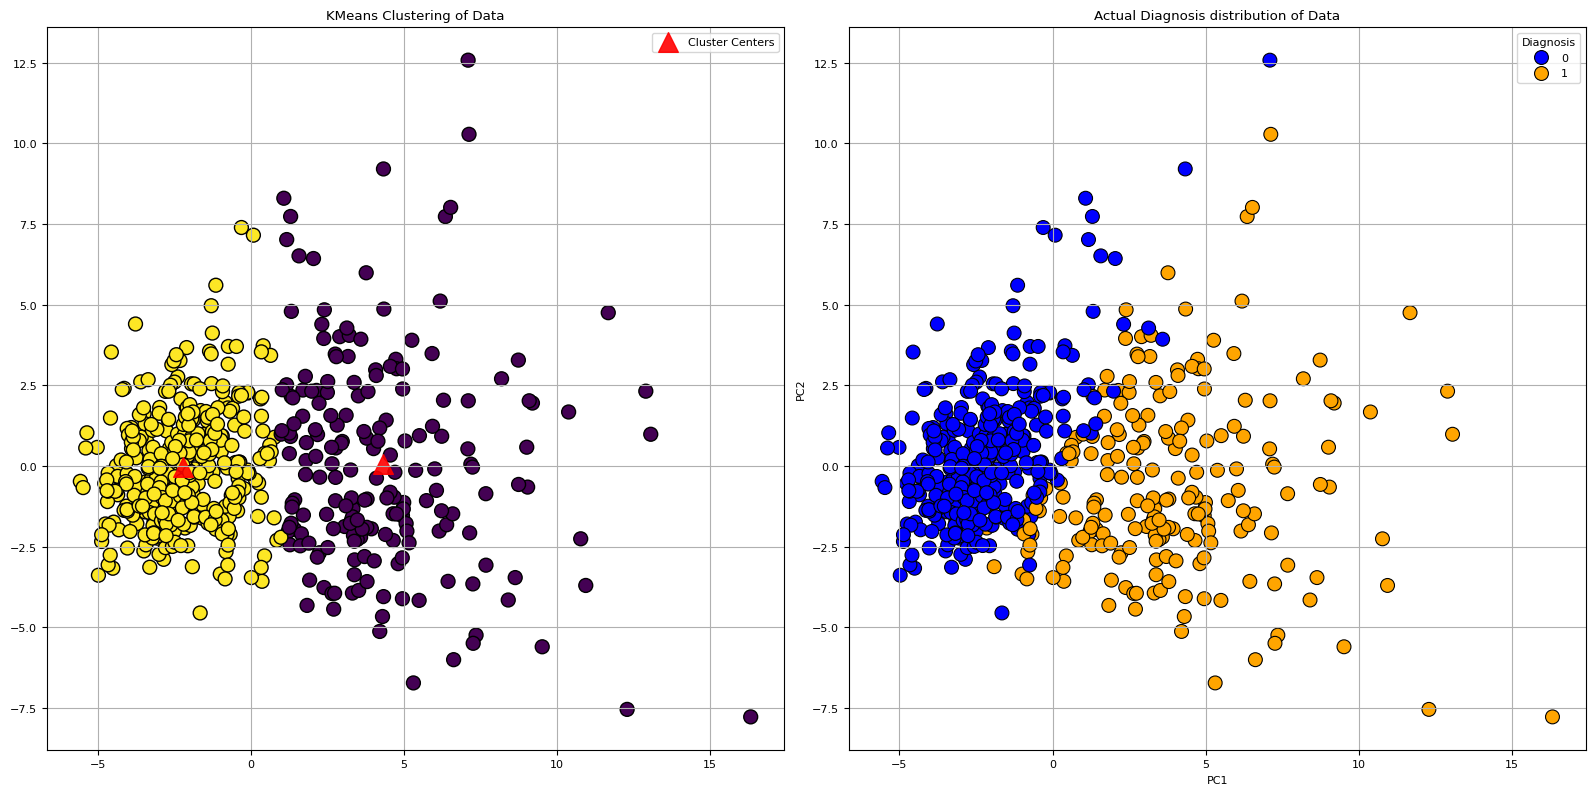

In [ ]:
# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# Plot 1: KMeans Clustering
ax1.scatter(x_pca[:, 0], x_pca[:, 1], c=labels, s=100, cmap='viridis', edgecolor='black')
centers = kmeans2.cluster_centers_
ax1.scatter(centers[:, 0], centers[:, 1], marker="^", c='red', 
            s=200, alpha=0.9, label='Cluster Centers')
ax1.set_title('KMeans Clustering of Data')
ax1.legend()
ax1.grid(True)

# Plot 2: Diagnosis Labels
sns.scatterplot(x='PC1', y='PC2', hue='Diagnosis', data=pca_df, palette=custom_palette, 
                 edgecolor='black', s=100, ax=ax2)
ax2.set_title('Actual Diagnosis distribution of Data')
ax2.legend(title='Diagnosis')
ax2.grid(True)

plt.tight_layout()
plt.show()

We can observe that if we had to separate the two clusters in the KMeans plot we can draw two circles centered around the centroid. On the other hand to separate the two diagnosis groups (benign and malignant) in the actual diagnosis plot we could draw a straight diagonal line, with some mixed unclear results at the decision boundary.

However besides these differences, we can see that most clear diagnostic cases match, and *k*-means made a rather acurate guess of the distribution. Lets plot them one on top of the other and see where we obtained missmatches.

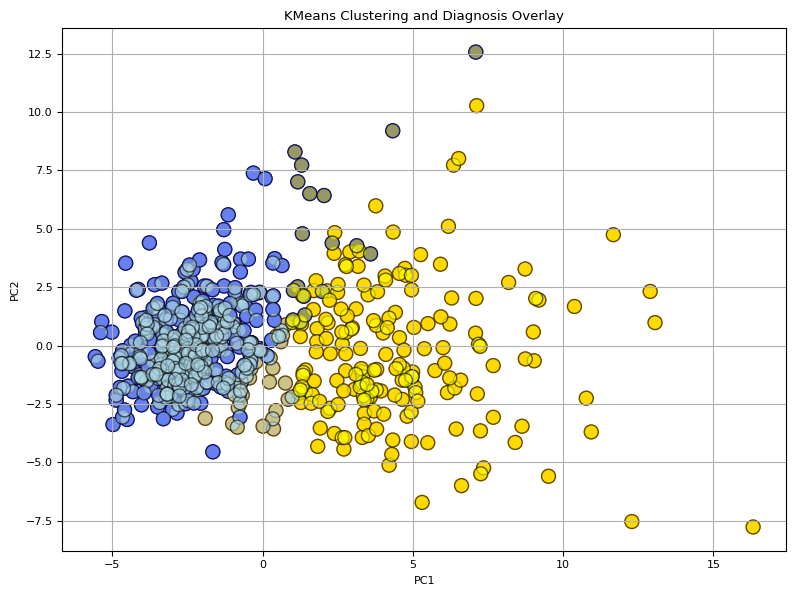

In [28]:
# Create a DataFrame for the PCA-transformed data
pca_df = pd.DataFrame(data=x_pca[:, :2], columns=['PC1', 'PC2'])

# Add the diagnosis column to the DataFrame
pca_df['Diagnosis'] = y.reset_index(drop=True)  # Ensure y aligns with x_pca

# Create a figure with a single subplot
fig, ax = plt.subplots(figsize=(8, 6))

# Plot 2: Diagnosis Labels (Overlay Layer)
diagnosis_colors = np.where(pca_df['Diagnosis'] == 0, 'blue', 'orange')
scatter2 = ax.scatter(x_pca[:, 0], x_pca[:, 1], c=diagnosis_colors, s=100, 
                      label='Diagnosis Labels')

# Plot 1: KMeans Clustering (Base Layer)
kmeans_colors = np.where(labels == 0, 'yellow', 'lightblue')
scatter1 = ax.scatter(x_pca[:, 0], x_pca[:, 1], c=kmeans_colors, 
                      s=100, edgecolor='black', alpha=0.6, label='KMeans Clusters')

# Add titles and labels
ax.set_title('KMeans Clustering and Diagnosis Overlay')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.grid(True)

plt.tight_layout()
plt.show()

#### *k*-means conclusions
We can observe that most points match, in blues (benign) and yellows (malignant), and those in different tones from blues and yellows are the missmatches. Therefore *k*-means performed a rather good classification of these two clusters of benign and malignant cells, without having any intrinsically insights on the data.

This means that our data truly falls under a marked distribution that could have been guessed by the closeness of the data points to each other.

### Further explorations with *k*-means

Even though we chose only two clusters during the analysis due to the fact that the data divides into two. We also wondered if we could use a greater number of clusters that could show some kind of subgroups of cells that were not captured during the experiment. To see this, we will observe how a different number of clusters divides the data.

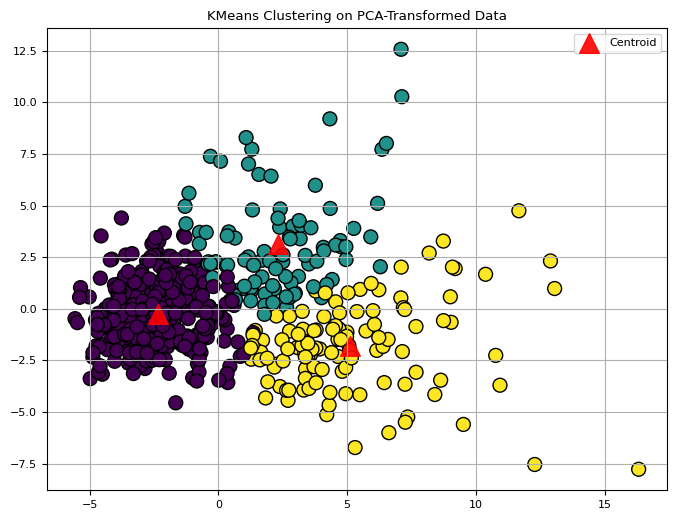

In [ ]:
# We perform KMeans clustering with three clusters
kmeans3 = KMeans(n_clusters=3, random_state=0)
kmeans3.fit(df_x_pca)
labels = kmeans3.predict(df_x_pca)

plt.figure(figsize=(8, 6))
plt.scatter(df_x_pca[:, 0], df_x_pca[:, 1], c=labels, s=100, cmap='viridis', edgecolor='black')

centers = kmeans3.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], marker="^", c='red', s=200, alpha=0.9, label='Centroid');

plt.title('KMeans Clustering on PCA-Transformed Data')

plt.grid(True)
plt.legend()
plt.show()

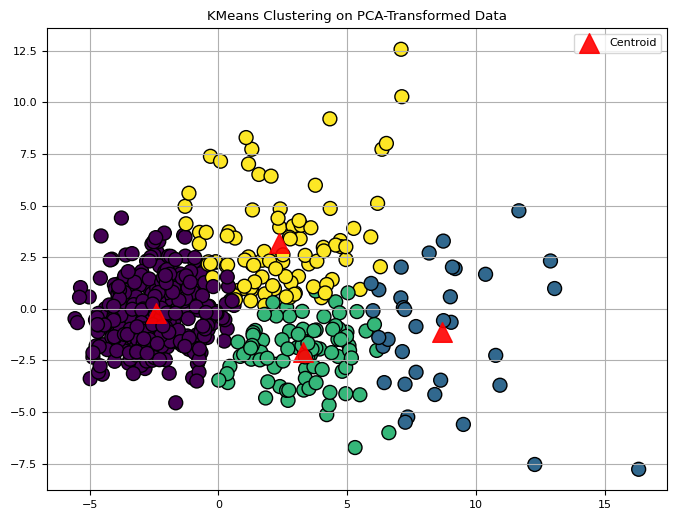

In [ ]:
# We perform KMeans clustering with four clusters
kmeans4 = KMeans(n_clusters=4, random_state=0)
kmeans4.fit(df_x_pca)
labels = kmeans4.predict(df_x_pca)

plt.figure(figsize=(8, 6))
plt.scatter(df_x_pca[:, 0], df_x_pca[:, 1], c=labels, s=100, cmap='viridis', edgecolor='black')

centers = kmeans4.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], marker="^", c='red', s=200, alpha=0.9, label='Centroid');

plt.title('KMeans Clustering on PCA-Transformed Data')

plt.grid(True)
plt.legend()
plt.show()

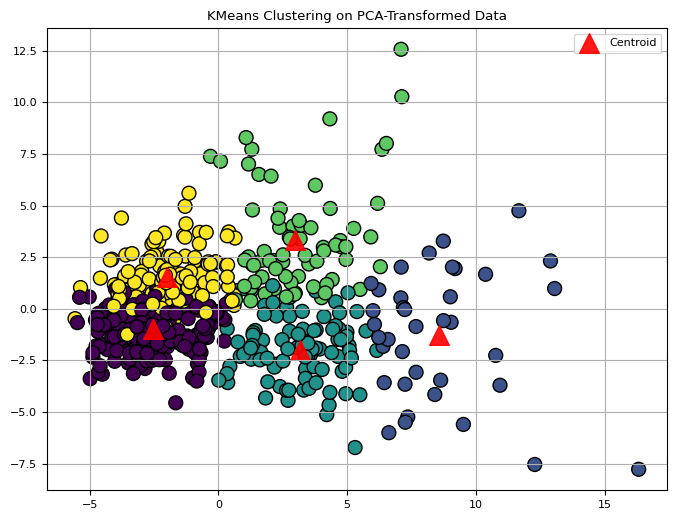

In [ ]:
# We perform KMeans clustering with five clusters
kmeans5 = KMeans(n_clusters=5, random_state=0)
kmeans5.fit(df_x_pca)
labels = kmeans5.predict(df_x_pca)

plt.figure(figsize=(8, 6))
plt.scatter(df_x_pca[:, 0], df_x_pca[:, 1], c=labels, s=100, cmap='viridis', edgecolor='black')

centers = kmeans5.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], marker="^", c='red', s=200, alpha=0.9, label='Centroid');

plt.title('KMeans Clustering on PCA-Transformed Data')

plt.grid(True)
plt.legend()
plt.show()

#### Conclusions

We can see that for three or four clusters, there is a division of the data with a possible biological interpretation. 
Since the benign cluster always remains and there is a subclustering of the malignant cluster. This subclustering may be due to a division of malignant cells into different tumour cell subpopulations or different stages.

However, this biological interpretation disappears when we use five cluster, because the benign cells, which shouldn`t be divided, are into two different clusters.

We can explore the optimal choice of clusters seeing the error produced by the choice of different numbers of clusters.

Text(0.5, 1.0, 'Value Cost Function per Number of Clusters')

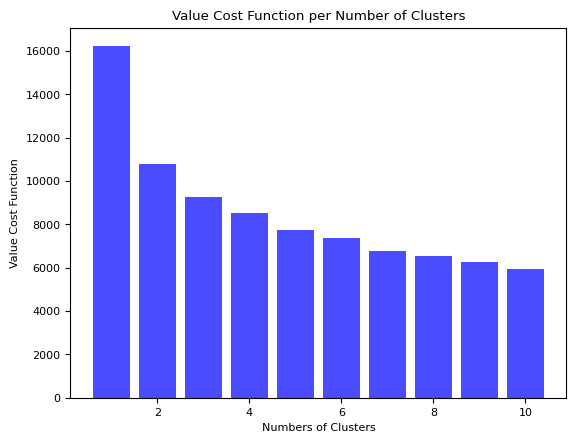

In [ ]:
Cost_function = []
for i in range(1,n_components+1):
    kmeansCheck = KMeans(n_clusters=i)
    kmeansCheck.fit(df_x_pca)
    Cost_function.append(kmeansCheck.inertia_)
plt.bar(range(1, n_components + 1), Cost_function, alpha=0.7, color='b')
plt.xlabel("Numbers of Clusters")
plt.ylabel("Value Cost Function")
plt.title("Value Cost Function per Number of Clusters")

`kmeansCheck.inertia_` measures how well the data points are clustered (lower values mean better clustering). Thererfore, we can conclude from this graph that the optimal choice of clusters is two or three, where the value of the cost function decreases the most.